# Digital Payment Fraud Detection

Fraud detection analysis on the PaySim synthetic mobile money dataset, covering exploratory analysis of fraud patterns by transaction type and amount, feature engineering, and a logistic regression model trained with SMOTE to handle severe class imbalance.

**Tools:** Python (Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn, Imbalanced-learn) · PostgreSQL · Tableau Public   

**Data source:** [PaySim Synthetic Financial Dataset](https://www.kaggle.com/datasets/ealaxi/paysim1) (Kaggle)

## 1. Data Loading & Overview

Load the raw transaction data and check its size, structure, and the overall class balance between legitimate and fraudulent transactions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

df = pd.read_csv('../data/paysim_fraud.csv')
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0


In [2]:
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (6362620, 11)

Column types:
step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [3]:
print("Class distribution (counts):")
print(df['isFraud'].value_counts())
print("\nClass distribution (%):")
print(df['isFraud'].value_counts(normalize=True) * 100)

Class distribution (counts):
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Class distribution (%):
isFraud
0   99.87
1    0.13
Name: proportion, dtype: float64


**Key finding:** The dataset has 6,362,620 transactions, with only 8,213 (0.13%) labeled as fraud. This severe class imbalance (roughly 1 fraud case per 774 legitimate transactions) is the central challenge of this project and directly motivates the use of SMOTE later in the modeling section, since a naive classifier could achieve 99.87% accuracy just by predicting "not fraud" every time.

## 2. Fraud Rate by Transaction Type

Check whether fraud is spread evenly across transaction types, or concentrated in specific ones. This determines which transactions are worth modeling at all.

In [4]:
print("Transaction type counts:")
print(df['type'].value_counts())

fraud_by_type = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum')
).assign(fraud_rate=lambda x: (x['fraud_count'] / x['total'] * 100).round(2))

print("\nFraud rate by transaction type:")
print(fraud_by_type.sort_values('fraud_count', ascending=False))

Transaction type counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate by transaction type:
            total  fraud_count  fraud_rate
type                                      
CASH_OUT  2237500         4116        0.18
TRANSFER   532909         4097        0.77
CASH_IN   1399284            0        0.00
DEBIT       41432            0        0.00
PAYMENT   2151495            0        0.00


**Key finding:** Fraud occurs exclusively in `TRANSFER` (0.77% fraud rate, 4,097 cases) and `CASH_OUT` (0.18% fraud rate, 4,116 cases) transactions. `CASH_IN`, `DEBIT`, and `PAYMENT` have zero fraud cases in this dataset. This is the most important finding in the entire EDA: it means over 3.5 million transactions (roughly 56% of the dataset) can be excluded from modeling entirely, since they contain no positive class examples to learn from.

## 3. Filter to Fraud-Prone Transaction Types

Restrict the dataset to `TRANSFER` and `CASH_OUT` transactions only, based on the finding above. This is the dataset used for all remaining analysis and modeling.

In [5]:
df_model = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

print(f"Filtered shape: {df_model.shape}")
print(f"\nClass distribution in filtered data:")
print(df_model['isFraud'].value_counts())

Filtered shape: (2770409, 11)

Class distribution in filtered data:
isFraud
0    2762196
1       8213
Name: count, dtype: int64


**Key finding:** The modeling dataset contains 2,770,409 transactions, with 8,213 fraud cases, meaning the class imbalance is now roughly 1:337 instead of 1:774, still severe but noticeably improved just by removing the fraud-free transaction types.

## 4. Transaction Amount Distribution

Compare the distribution of transaction amounts between legitimate and fraudulent transactions, for `TRANSFER` and `CASH_OUT` separately. A log scale is used since transaction amounts are heavily right-skewed.

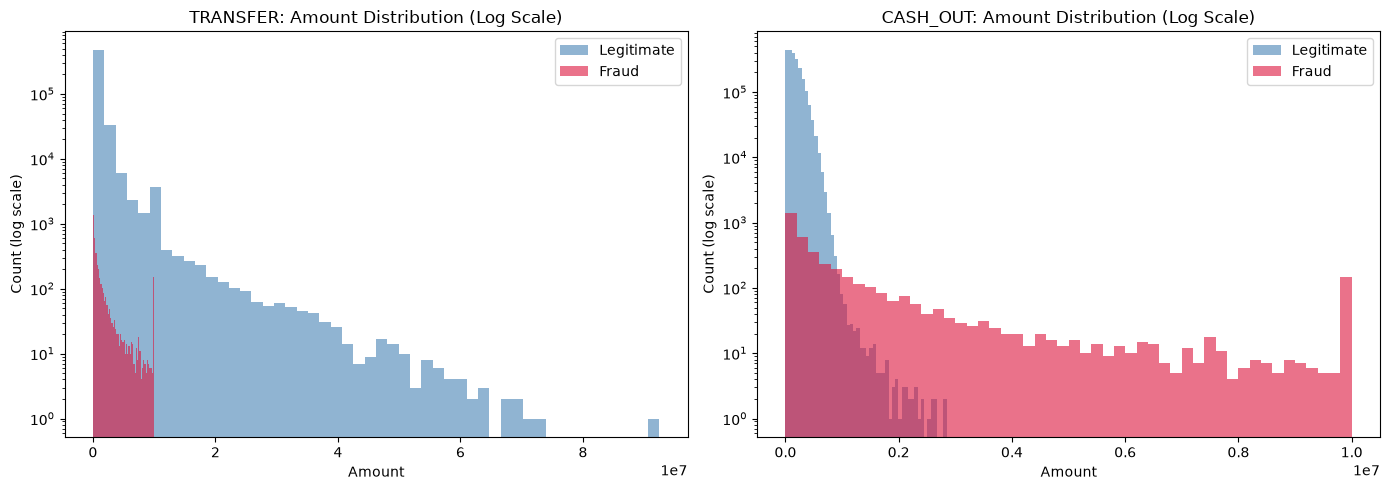

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tx_type in zip(axes, ['TRANSFER', 'CASH_OUT']):
    subset = df_model[df_model['type'] == tx_type]
    ax.hist(subset[subset['isFraud'] == 0]['amount'], bins=50, alpha=0.6,
            label='Legitimate', color='steelblue', log=True)
    ax.hist(subset[subset['isFraud'] == 1]['amount'], bins=50, alpha=0.6,
            label='Fraud', color='crimson', log=True)
    ax.set_title(f'{tx_type}: Amount Distribution (Log Scale)')
    ax.set_xlabel('Amount')
    ax.set_ylabel('Count (log scale)')
    ax.legend()

plt.tight_layout()
plt.savefig('../tableau/amount_distribution.png', dpi=150)
plt.show()

<Figure size 800x500 with 0 Axes>

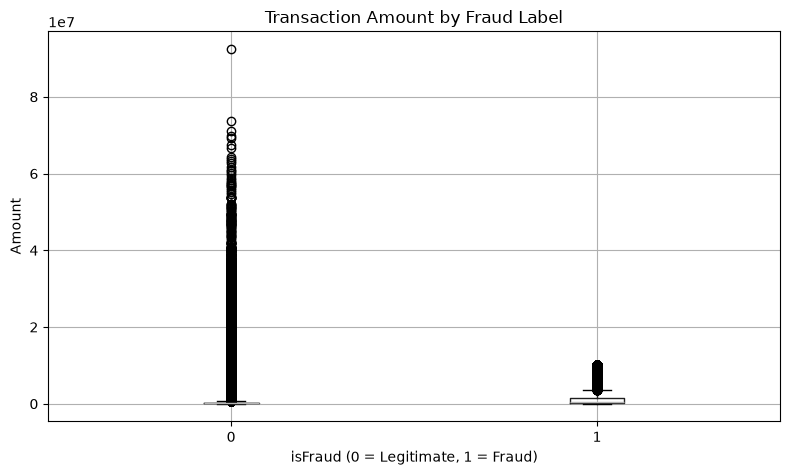

In [7]:
plt.figure(figsize=(8, 5))
df_model.boxplot(column='amount', by='isFraud', figsize=(8, 5))
plt.title('Transaction Amount by Fraud Label')
plt.suptitle('')
plt.xlabel('isFraud (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Amount')
plt.tight_layout()
plt.show()

**Key finding:** Fraudulent transactions skew notably higher than legitimate ones: mean amount is ₹1,467,967 for fraud vs ₹314,115 for legitimate (nearly 5x higher), and the median gap tells the same story (₹441,423 vs ₹171,034). Interestingly, fraud amounts cap out at exactly ₹10,000,000 (visible as a spike at the right edge of the CASH_OUT log-scale histogram), while legitimate transactions occasionally go much higher, up to ₹92.4M, suggesting fraudsters in this dataset operate under an implicit ceiling rather than targeting the largest possible transfers.

## 5. Fraud vs Legitimate Volume by Type

Visualize the raw count comparison and the fraud rate side by side for `TRANSFER` and `CASH_OUT`, to see the split clearly rather than just from the table above.

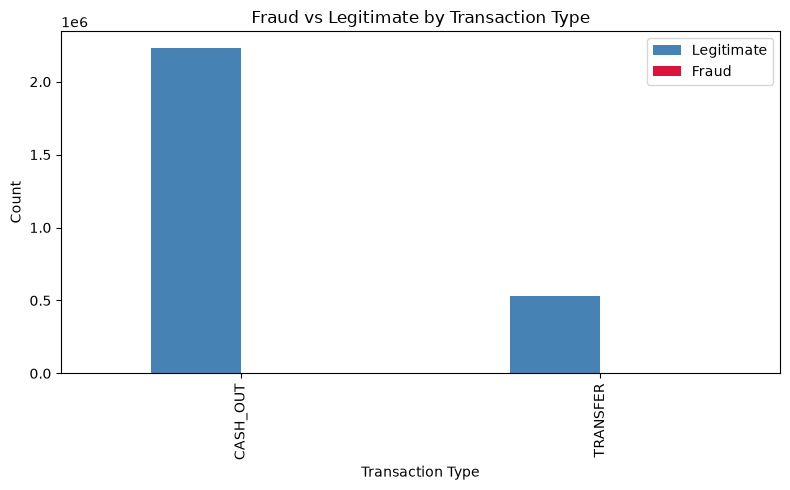

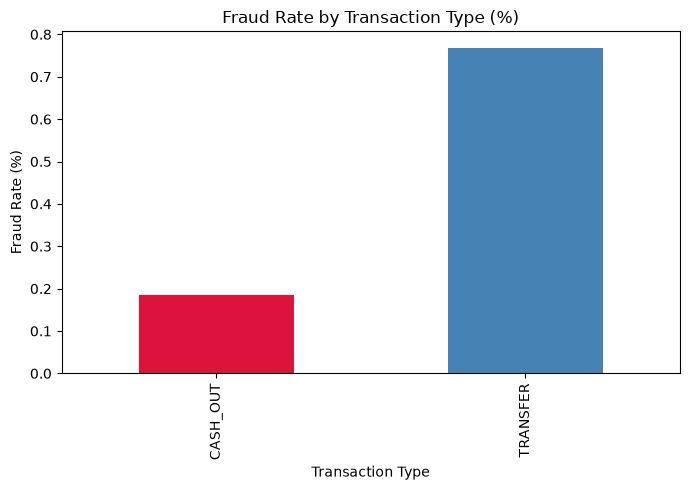

In [8]:
type_fraud = df_model.groupby(['type', 'isFraud']).size().unstack()
type_fraud.plot(kind='bar', figsize=(8, 5), color=['steelblue', 'crimson'])
plt.title('Fraud vs Legitimate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(['Legitimate', 'Fraud'])
plt.tight_layout()
plt.show()

fraud_rate = df_model.groupby('type')['isFraud'].mean() * 100
fraud_rate.plot(kind='bar', figsize=(7, 5), color=['crimson', 'steelblue'])
plt.title('Fraud Rate by Transaction Type (%)')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

**Key finding:** Even though `CASH_OUT` has slightly more absolute fraud cases (4,116 vs 4,097), `TRANSFER` has a substantially higher fraud *rate* (0.77% vs 0.18%), over 4x higher. This distinction matters for the model, since amount and type together should carry more signal than volume alone would suggest.

## 6. Balance-Based Feature Engineering

Engineer features from the sender's and receiver's account balances. A key PaySim pattern: fraudulent transfers often drain the sender's account to exactly zero, since the fraud mechanic empties the account rather than leaving a partial balance.

In [9]:
df_model['balance_diff_orig'] = df_model['oldbalanceOrg'] - df_model['newbalanceOrig']
df_model['balance_diff_dest'] = df_model['oldbalanceDest'] - df_model['newbalanceDest']
df_model['orig_balance_zero'] = (df_model['newbalanceOrig'] == 0).astype(int)

print("Average balance change (sender), by fraud label:")
print(df_model.groupby('isFraud')['balance_diff_orig'].mean())

print("\nAverage destination balance, by fraud label:")
print(df_model.groupby('isFraud')['newbalanceDest'].mean())

print("\n% of transactions where sender's balance goes to exactly zero, by fraud label:")
print(df_model.groupby('isFraud')['orig_balance_zero'].mean() * 100)

Average balance change (sender), by fraud label:
isFraud
0     27311.99
1   1457274.97
Name: balance_diff_orig, dtype: float64

Average destination balance, by fraud label:
isFraud
0   2052024.00
1   1279707.62
Name: newbalanceDest, dtype: float64

% of transactions where sender's balance goes to exactly zero, by fraud label:
isFraud
0   90.10
1   98.05
Name: orig_balance_zero, dtype: float64


**Key finding:** Fraudulent transactions drain the sender's account far more aggressively: the average balance change is ₹1,457,275 for fraud vs just ₹27,312 for legitimate transactions, over 50x higher. The "zero balance" signal is real but less dramatic than expected: 98.05% of fraud cases leave the sender's balance at exactly zero, compared to 90.10% of legitimate ones. Both groups zero out often (a common pattern in this transaction type), so this feature adds a real but modest signal on its own, it's more useful combined with balance_diff_orig.

## 7. Amount Summary Statistics and Feature Correlation

Summarize transaction amount statistics by fraud label, then check how the engineered features correlate with each other and with the fraud label, both to sanity-check the feature engineering and to catch any redundant (highly correlated) features before modeling.

In [10]:
print("Amount summary statistics by fraud label:")
print(df_model.groupby('isFraud')['amount'].describe())

Amount summary statistics by fraud label:
             count       mean        std  min       25%       50%        75%  \
isFraud                                                                        
0       2762196.00  314115.50  877144.15 0.01  82908.23 171034.46  305994.18   
1          8213.00 1467967.30 2404252.95 0.00 127091.33 441423.44 1517771.48   

                max  
isFraud              
0       92445516.64  
1       10000000.00  


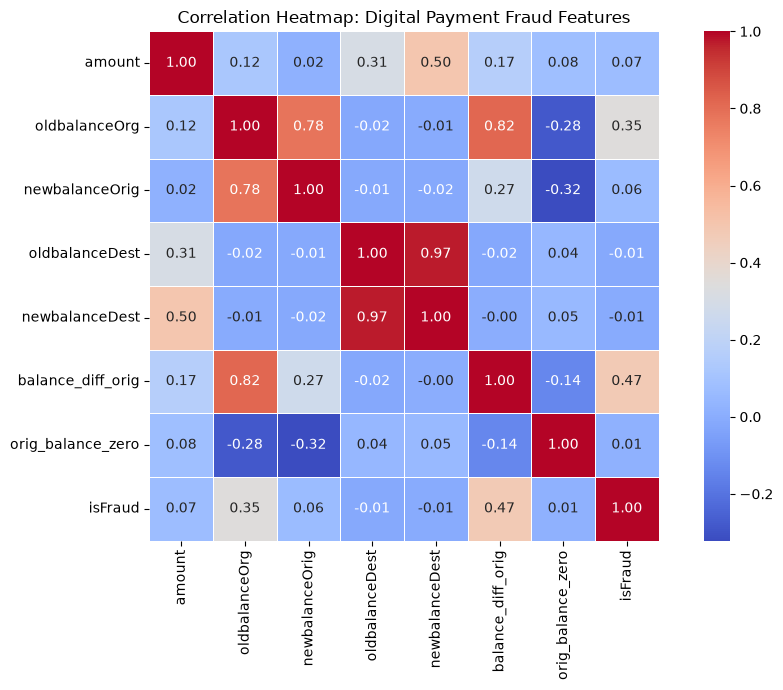

In [11]:
plt.figure(figsize=(10, 7))

numeric_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
                'oldbalanceDest', 'newbalanceDest',
                'balance_diff_orig', 'orig_balance_zero', 'isFraud']

corr = df_model[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)

plt.title('Correlation Heatmap: Digital Payment Fraud Features')
plt.tight_layout()
plt.show()

**Key finding:** balance_diff_orig is the strongest single correlate of fraud (0.47), consistent with the pattern above, fraud transactions drain far more from the sender. oldbalanceOrg follows at 0.35. As expected, oldbalanceOrg and newbalanceOrig are highly correlated with each other (0.78), some redundancy between them, but both were kept since logistic regression handles correlated inputs reasonably well and each still contributes distinct information once combined with the engineered features.

## 8. Fraud Prediction Model

Train a logistic regression model to classify transactions as fraud or legitimate. Given the severe class imbalance (0.3% fraud in the modeling subset), SMOTE oversampling is applied to the training set only, and `class_weight='balanced'` is used to further penalize misclassifying the minority class.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

df_model['type_encoded'] = (df_model['type'] == 'TRANSFER').astype(int)

features = ['amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'balance_diff_orig',
            'orig_balance_zero', 'type_encoded']

X = df_model[features]
y = df_model['isFraud']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

Train size: (2216327, 7)
Test size: (554082, 7)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
sm = SMOTE(random_state=42, sampling_strategy=0.1)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_res).value_counts().to_dict()}")

Before SMOTE: {0: 2209757, 1: 6570}
After SMOTE: {0: 2209757, 1: 220975}


In [16]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train_res, y_train_res)

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

**Key finding:** SMOTE oversamples the training set's fraud cases from 6,570 to 220,975 (a 10% minority ratio, controlled by `sampling_strategy=0.1`), giving the model enough fraud examples to learn from without fully balancing the classes to 50/50, which tends to overcorrect and increase false positives further than necessary.

## 9. Model Evaluation

Evaluate the model on the held-out test set (which was never touched by SMOTE, preserving the real-world class imbalance) using precision, recall, the confusion matrix, and ROC-AUC.

In [17]:
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98    552439
       Fraud       0.09      0.97      0.16      1643

    accuracy                           0.97    554082
   macro avg       0.54      0.97      0.57    554082
weighted avg       1.00      0.97      0.98    554082



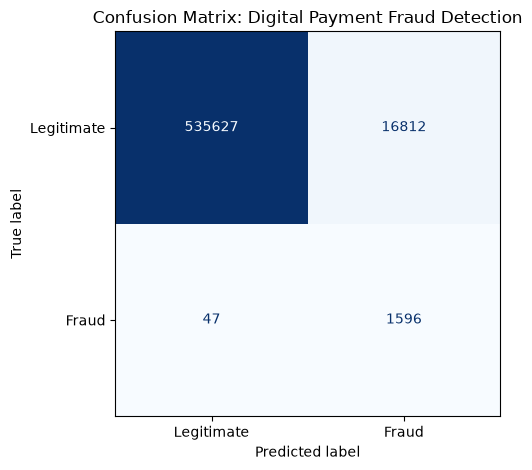

In [18]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legitimate', 'Fraud'])
disp.plot(cmap='Blues', colorbar=False)
plt.title('Confusion Matrix: Digital Payment Fraud Detection')
plt.tight_layout()
plt.show()

ROC-AUC Score: 0.9937


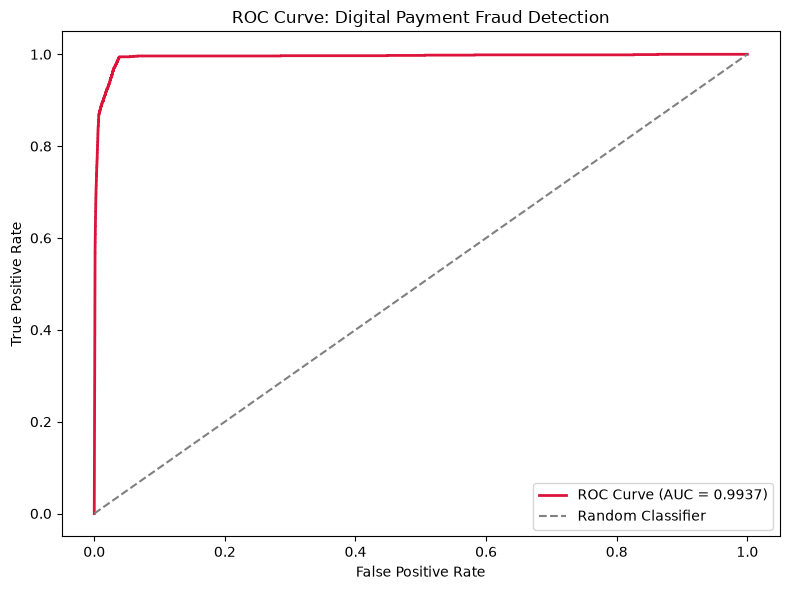

In [19]:
roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='crimson', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Digital Payment Fraud Detection')
plt.legend()
plt.tight_layout()
plt.show()

**Key finding:** The model achieves a ROC-AUC of 0.9937, meaning it separates fraud from legitimate transactions very well overall. Recall on fraud is 0.97, so the model correctly flags 97% of actual fraud cases, the priority metric for a fraud system, since missed fraud (false negatives) is typically far costlier than a false alarm. Precision on fraud is low at 0.09 (91% of flagged transactions turn out to be legitimate), a deliberate and expected trade-off given `class_weight='balanced'` and SMOTE were tuned to prioritize catching fraud over minimizing false alarms. In production, this would pair with a manual review queue for flagged transactions rather than automatic blocking, since a 9% precision means most flags need human confirmation.

## 10. Feature Importance

Examine the logistic regression coefficients to see which features drive the model's fraud predictions, and in which direction.

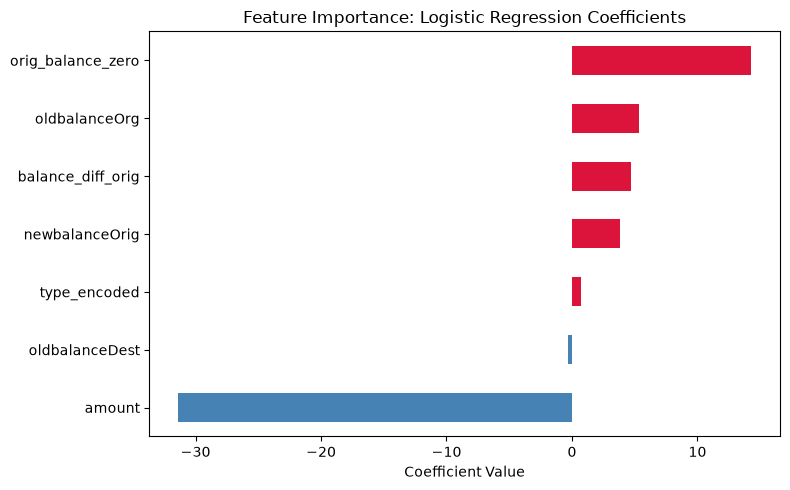

orig_balance_zero    14.29
oldbalanceOrg         5.36
balance_diff_orig     4.69
newbalanceOrig        3.81
type_encoded          0.72
oldbalanceDest       -0.31
amount              -31.39
dtype: float64


In [20]:
coefficients = pd.Series(model.coef_[0], index=features).sort_values()

plt.figure(figsize=(8, 5))
coefficients.plot(kind='barh', color=['crimson' if c > 0 else 'steelblue' for c in coefficients])
plt.title('Feature Importance: Logistic Regression Coefficients')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

print(coefficients.sort_values(ascending=False))

**Key finding:** orig_balance_zero is by far the strongest positive driver of fraud predictions (coefficient 14.29), consistent with Section 6. Notably, amount has the largest negative coefficient (-31.39), which looks counterintuitive given fraud transactions have higher raw amounts (Section 4), but reflects multicollinearity: once the balance-based features are in the model, amount's marginal contribution shifts direction rather than adding independent signal on its own.

## 11. Export for SQL and Tableau

Export the filtered modeling dataset and a fraud-only subset, used for the SQL analysis layer and the Tableau dashboard.

In [21]:
df_model.to_csv('../sql/fraud_model_data.csv', index=False)

fraud_only = df_model[df_model['isFraud'] == 1]
fraud_only.to_csv('../sql/fraud_transactions.csv', index=False)

print(f"fraud_model_data.csv: {df_model.shape}")
print(f"fraud_transactions.csv: {fraud_only.shape}")

fraud_model_data.csv: (2770409, 15)
fraud_transactions.csv: (8213, 15)


## Key Findings Summary

- **Class imbalance:** Only 0.13% of all transactions are fraudulent (8,213 of 6.36M), the central challenge driving every modeling decision in this project.
- **Fraud is type-specific:** Fraud occurs exclusively in `TRANSFER` and `CASH_OUT` transactions; three other transaction types have zero fraud cases and were excluded from modeling.
- **Fraud mechanic:** Fraud transactions drain the sender's account far more (avg ₹1.46M vs ₹27K balance change) and are somewhat more likely to zero it out (98% vs 90%), with balance_diff_orig the strongest single correlate of fraud (0.47).
- **Model performance:** ROC-AUC of 0.9937 with 97% recall on fraud, prioritizing catching fraud over minimizing false alarms, an appropriate trade-off for a first-pass detection system feeding a manual review queue.
- **Top drivers:** orig_balance_zero and oldbalanceOrg are the strongest positive drivers of fraud predictions; amount has a large negative coefficient due to multicollinearity with the balance features, an interesting nuance worth explaining if asked.

**Full interactive dashboard:** [Tableau Public link](https://public.tableau.com/views/DigitalPaymentFraudDetectionDashboard/Dashboard1?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link) · **SQL queries:** see the `/sql` folder in this repository